# **Load data**

In [1]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
from IPython.display import display
import matplotlib.pyplot as plt

CLEANED_FILE = "/kaggle/input/datasets/ahsanrizvimeow/amazon-product-intelligence-cleaned/products_cleaned.json"

with open(CLEANED_FILE, encoding="utf-8") as f:
    data = json.load(f)
df = pd.DataFrame(data)

print(f"Products: {len(df)}")
print(f"With real (non-imputed) price: {(~df['price_was_imputed']).sum()}")
print(f"With imputed price: {df['price_was_imputed'].sum()}")
display(df[["asin", "search_keyword", "title", "brand", "price",
            "price_was_imputed", "rating", "review_count"]].head())


Products: 1005
With real (non-imputed) price: 856
With imputed price: 149


,asin,search_keyword,title,brand,price,price_was_imputed,rating,review_count
0,B0D2HJDH94,wireless earbuds,"Wireless Bluetooth 5.4 Earbuds, LED Power Disp...",Jxrev,19.99,False,4.3,16257.0
1,B09JYJ6JKH,wireless earbuds,"Neckband Bluetooth Headphones, 24H Playtime Wi...",YOSDOM,27.99,False,4.0,2856.0
2,B0H9LHWBDK,wireless earbuds,"Wireless Earbuds, 2026 Bluetooth 5.4 Headphone...",XIAOWTEK,19.99,False,4.6,763.0
3,B0H7R1LD7B,wireless earbuds,"HAOYUYAN Wireless Earbuds, Sports Bluetooth He...",HAOYUYAN,23.98,False,4.6,343.0
4,B0G7H6K1WN,wireless earbuds,"Wireless Earbuds,Bluetooth 5.4 Ear buds,Sport ...",KTGEE,16.99,False,4.7,346.0


# **Define price tiers by within-category quantiles**

In [2]:
real_price = df[~df["price_was_imputed"]].copy()
print(f"Using {len(real_price)} products with genuine prices for tier definition")

def assign_tier(group):
    q33, q67 = group["price"].quantile([0.333, 0.667])
    def tier(p):
        if p <= q33:
            return "budget"
        if p <= q67:
            return "mid-range"
        return "premium"
    group["price_tier"] = group["price"].apply(tier)
    return group

real_price = real_price.groupby("search_keyword", group_keys=False).apply(assign_tier)

print("\nTier distribution:")
display(real_price["price_tier"].value_counts())

print("\nPrice range per tier, per category (sample):")
bounds = (real_price.groupby(["search_keyword", "price_tier"])["price"]
          .agg(["min", "max", "count"]).round(2))
display(bounds.head(15))

Using 856 products with genuine prices for tier definition

Tier distribution:


/tmp/ipykernel_58/598418226.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  real_price = real_price.groupby("search_keyword", group_keys=False).apply(assign_tier)


price_tier
budget       297
premium      281
mid-range    278
Name: count, dtype: int64


Price range per tier, per category (sample):


min      max  count
search_keyword    price_tier                        
DSLR camera       budget       16.98    89.99      4
                  mid-range   153.00   529.00      5
                  premium     549.00  1328.84      4
USB-C hub         budget        8.94    16.14      5
                  mid-range    19.99    39.99      5
                  premium      45.99    79.99      5
air purifier      budget       25.99    66.41      4
                  mid-range    69.98    99.99      4
                  premium     102.99   189.99      4
backpack          budget       14.44    27.99      6
                  mid-range    29.69    36.97      4
                  premium      43.97    94.99      5
bluetooth speaker budget       19.97    29.97      4
                  mid-range    29.99    78.99      3
                  premium      99.99   199.99      4

# **EDA — do tiers make sense?**

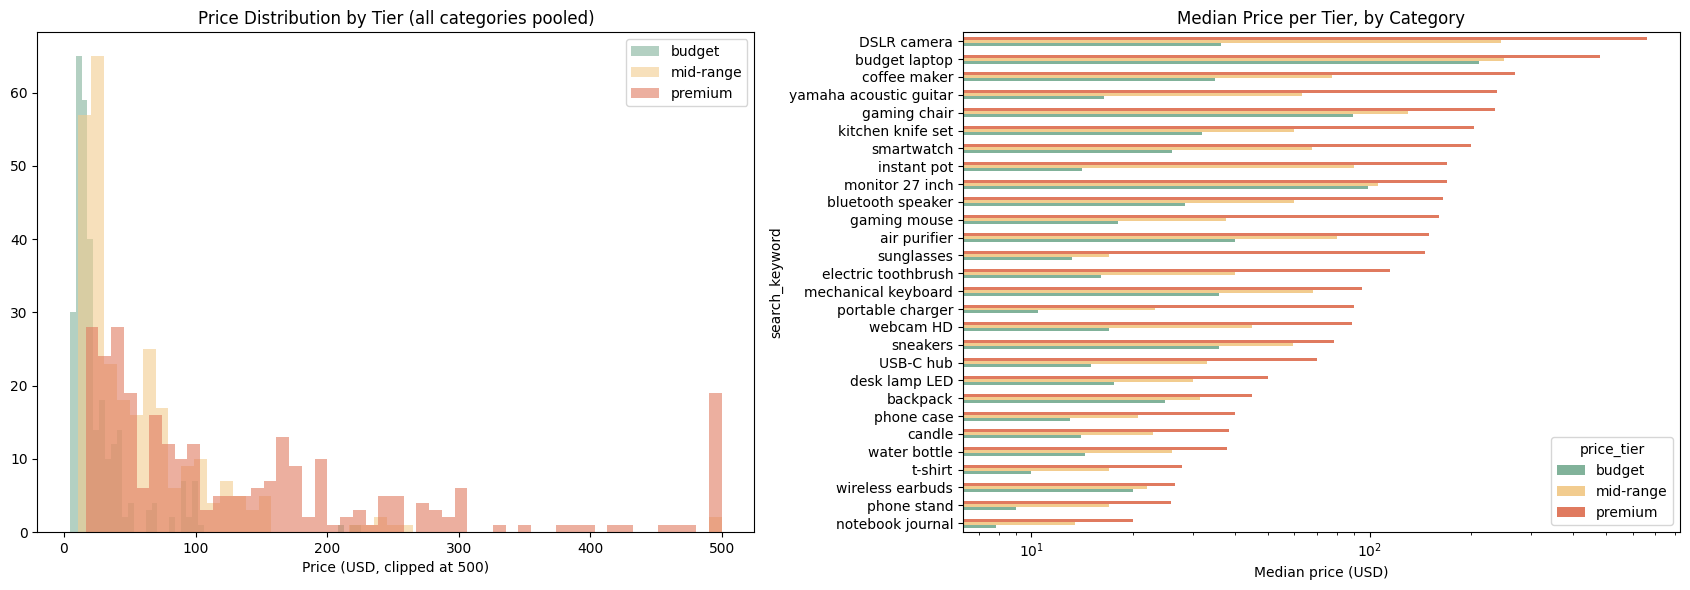

Note the log scale: 'premium' means something very different per category —
this is why tiers are defined within category, not globally.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

for tier, color in [("budget", "#81b29a"), ("mid-range", "#f2cc8f"), ("premium", "#e07a5f")]:
    subset = real_price[real_price["price_tier"] == tier]["price"]
    axes[0].hist(subset.clip(upper=500), bins=50, alpha=0.6, label=tier, color=color)
axes[0].set_xlabel("Price (USD, clipped at 500)")
axes[0].set_title("Price Distribution by Tier (all categories pooled)")
axes[0].legend()

cat_medians = (real_price.groupby(["search_keyword", "price_tier"])["price"]
               .median().unstack())
cat_medians = cat_medians[["budget", "mid-range", "premium"]].sort_values("premium")
cat_medians.plot(kind="barh", ax=axes[1], color=["#81b29a", "#f2cc8f", "#e07a5f"])
axes[1].set_xlabel("Median price (USD)")
axes[1].set_title("Median Price per Tier, by Category")
axes[1].set_xscale("log")

plt.tight_layout()
plt.show()

print("Note the log scale: 'premium' means something very different per category —")
print("this is why tiers are defined within category, not globally.")

# **Build features — CRITICAL: no price-derived data**

In [4]:
real_price["bullet_text"] = real_price["bullet_points"].apply(
    lambda b: " ".join(b) if isinstance(b, list) else "")
real_price["text_features"] = (real_price["title"].fillna("") + " " +
                                real_price["brand"].fillna("") + " " +
                                real_price["bullet_text"])

real_price["title_length"] = real_price["title"].str.len()
real_price["bullet_count"] = real_price["bullet_points"].apply(
    lambda b: len(b) if isinstance(b, list) else 0)
real_price["has_brand"] = (real_price["brand"].fillna("") != "").astype(int)

feature_check = ["text_features", "title_length", "bullet_count", "has_brand",
                 "rating", "review_count", "search_keyword"]

print("=" * 70)
print("LEAKAGE CHECK — features used for prediction")
print("=" * 70)
for f in feature_check:
    print(f"  {f}")
print("\nExcluded (would leak the answer): price, price_clean, price_imputed, price_was_imputed")

price_words = real_price["text_features"].str.contains(
    r"\$|\bprice\b|\bcheap\b|\bbudget\b|\bpremium\b|\baffordable\b|\bexpensive\b",
    case=False, regex=True)
print(f"\nProducts whose text mentions price-related words: {price_words.sum()} "
      f"({price_words.mean()*100:.1f}%)")
print("These are kept — the words are part of genuine product descriptions,")
print("not the numeric price. Worth noting as a potential weak signal.")

LEAKAGE CHECK — features used for prediction
  text_features
  title_length
  bullet_count
  has_brand
  rating
  review_count
  search_keyword

Excluded (would leak the answer): price, price_clean, price_imputed, price_was_imputed

Products whose text mentions price-related words: 157 (18.3%)
These are kept — the words are part of genuine product descriptions,
not the numeric price. Worth noting as a potential weak signal.


Train: 642  Test: 214
Feature matrix: (642, 3033)
  TF-IDF text: 3000
  Category one-hot: 28
  Numeric: 5
Trained: Baseline (most frequent)
Trained: Logistic Regression
Trained: Random Forest
Trained: Gradient Boosting

MODEL COMPARISON


,model,accuracy,macro_f1,budget_f1,midrange_f1,premium_f1
3,Gradient Boosting,0.486,0.476,0.566,0.355,0.507
1,Logistic Regression,0.453,0.444,0.512,0.331,0.489
2,Random Forest,0.421,0.406,0.482,0.261,0.476
0,Baseline (most frequent),0.346,0.171,0.514,0.000,0.000



Best model: Gradient Boosting

              precision    recall  f1-score   support

      budget      0.511     0.635     0.566        74
   mid-range      0.407     0.314     0.355        70
     premium      0.515     0.500     0.507        70

    accuracy                          0.486       214
   macro avg      0.478     0.483     0.476       214
weighted avg      0.478     0.486     0.478       214

5-fold CV macro-F1:

Logistic Regression     0.481 (+/- 0.034)
Random Forest           0.519 (+/- 0.048)
Gradient Boosting       0.493 (+/- 0.026)


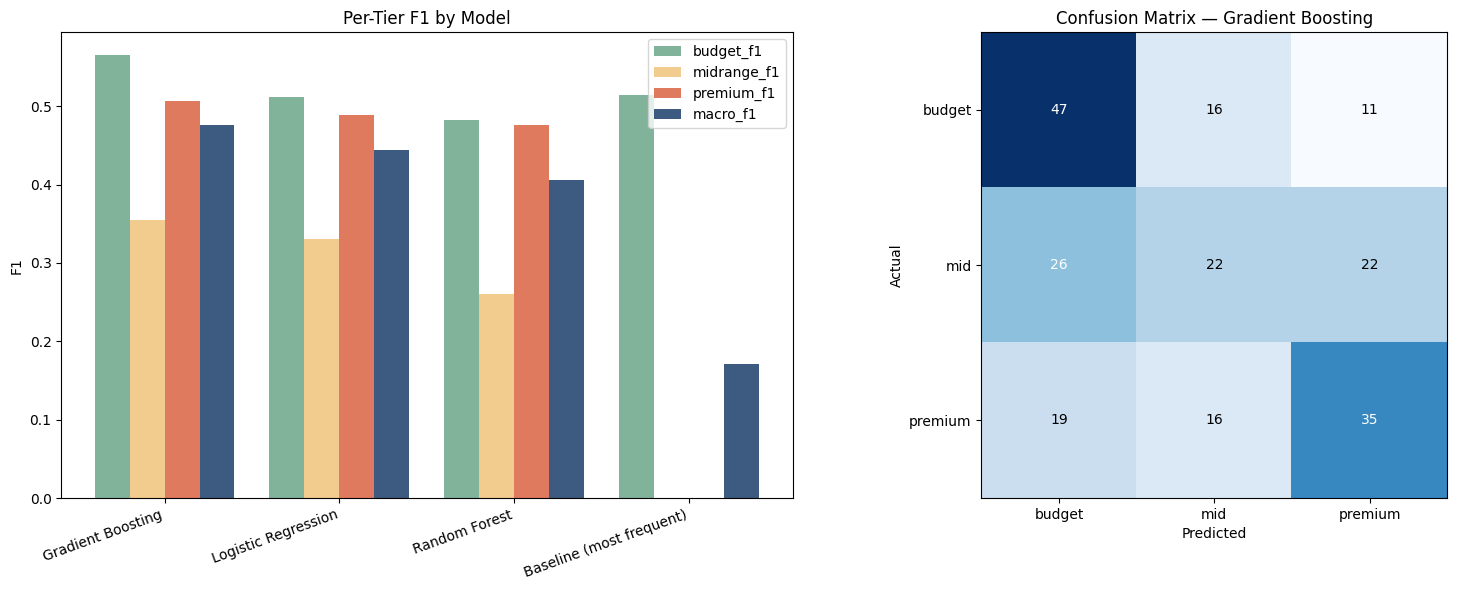

In [5]:
# ============================================================
# CELL: Build feature matrix
# ============================================================
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from scipy.sparse import hstack, csr_matrix

model_df = real_price.copy()
model_df["review_count"] = model_df["review_count"].fillna(model_df["review_count"].median())
model_df["rating"] = model_df["rating"].fillna(model_df["rating"].median())

X_train_df, X_test_df, y_train, y_test = train_test_split(
    model_df, model_df["price_tier"], test_size=0.25,
    random_state=42, stratify=model_df["price_tier"])

print(f"Train: {len(X_train_df)}  Test: {len(X_test_df)}")

tfidf = TfidfVectorizer(stop_words="english", max_features=3000,
                        ngram_range=(1, 2), min_df=2, sublinear_tf=True)
Xtr_text = tfidf.fit_transform(X_train_df["text_features"])
Xte_text = tfidf.transform(X_test_df["text_features"])

cat_enc = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
Xtr_cat = cat_enc.fit_transform(X_train_df[["search_keyword"]])
Xte_cat = cat_enc.transform(X_test_df[["search_keyword"]])

num_cols = ["title_length", "bullet_count", "has_brand", "rating", "review_count"]
scaler = StandardScaler()
Xtr_num = csr_matrix(scaler.fit_transform(X_train_df[num_cols]))
Xte_num = csr_matrix(scaler.transform(X_test_df[num_cols]))

X_train = hstack([Xtr_text, Xtr_cat, Xtr_num]).tocsr()
X_test = hstack([Xte_text, Xte_cat, Xte_num]).tocsr()

print(f"Feature matrix: {X_train.shape}")
print(f"  TF-IDF text: {Xtr_text.shape[1]}")
print(f"  Category one-hot: {Xtr_cat.shape[1]}")
print(f"  Numeric: {Xtr_num.shape[1]}")


# ============================================================
# CELL: Train and compare models
# ============================================================
models = {
    "Baseline (most frequent)": DummyClassifier(strategy="most_frequent", random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                            random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, random_state=42),
}

results, preds = [], {}
for name, model in models.items():
    model.fit(X_train, y_train)
    p = model.predict(X_test)
    preds[name] = p
    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, p),
        "macro_f1": f1_score(y_test, p, average="macro"),
        "budget_f1": f1_score(y_test, p, labels=["budget"], average=None, zero_division=0)[0],
        "midrange_f1": f1_score(y_test, p, labels=["mid-range"], average=None, zero_division=0)[0],
        "premium_f1": f1_score(y_test, p, labels=["premium"], average=None, zero_division=0)[0],
    })
    print(f"Trained: {name}")

results_df = pd.DataFrame(results).sort_values("macro_f1", ascending=False).round(3)
print("\n" + "=" * 70)
print("MODEL COMPARISON")
print("=" * 70)
display(results_df)

best_name = results_df.iloc[0]["model"]
print(f"\nBest model: {best_name}\n")
print(classification_report(y_test, preds[best_name],
                            labels=["budget", "mid-range", "premium"],
                            digits=3, zero_division=0))


# ============================================================
# CELL: Cross-validation for reliability
# ============================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("5-fold CV macro-F1:\n")
for name, model in models.items():
    if name.startswith("Baseline"):
        continue
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1_macro", n_jobs=-1)
    print(f"{name:22s}  {scores.mean():.3f} (+/- {scores.std():.3f})")


# ============================================================
# CELL: Visualize and inspect what the model learned
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(len(results_df))
w = 0.2
for i, (m, c) in enumerate([("budget_f1", "#81b29a"), ("midrange_f1", "#f2cc8f"),
                             ("premium_f1", "#e07a5f"), ("macro_f1", "#3d5a80")]):
    axes[0].bar(x + i*w, results_df[m], w, label=m, color=c)
axes[0].set_xticks(x + w*1.5)
axes[0].set_xticklabels(results_df["model"], rotation=20, ha="right")
axes[0].set_ylabel("F1")
axes[0].set_title("Per-Tier F1 by Model")
axes[0].legend()

cm = confusion_matrix(y_test, preds[best_name], labels=["budget", "mid-range", "premium"])
axes[1].imshow(cm, cmap="Blues")
axes[1].set_xticks(range(3)); axes[1].set_xticklabels(["budget", "mid", "premium"])
axes[1].set_yticks(range(3)); axes[1].set_yticklabels(["budget", "mid", "premium"])
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")
axes[1].set_title(f"Confusion Matrix — {best_name}")
for i in range(3):
    for j in range(3):
        axes[1].text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max()/2 else "black")
plt.tight_layout()
plt.show()

if best_name == "Logistic Regression":
    feat_names = (list(tfidf.get_feature_names_out()) +
                  list(cat_enc.get_feature_names_out()) + num_cols)
    best_model = models[best_name]
    for i, tier in enumerate(best_model.classes_):
        coefs = best_model.coef_[i]
        top = np.argsort(coefs)[-15:][::-1]
        print(f"\nTop indicators of '{tier}':")
        print("  " + ", ".join(feat_names[j] for j in top))

MODEL SELECTION — 5-fold CV on training data only
Preprocessing fitted inside each fold (no leakage)
Logistic Regression     0.482 (+/- 0.033)
Random Forest           0.509 (+/- 0.041)
Gradient Boosting       0.498 (+/- 0.014)


,model,cv_macro_f1,cv_std
1,Random Forest,0.509,0.041
2,Gradient Boosting,0.498,0.014
0,Logistic Regression,0.482,0.033



Selected by CV: Random Forest

FINAL EVALUATION — held-out test set, used once
Model: Random Forest
Test accuracy: 0.421
Test macro-F1: 0.406

              precision    recall  f1-score   support

      budget      0.435     0.541     0.482        74
   mid-range      0.333     0.214     0.261        70
     premium      0.455     0.500     0.476        70

    accuracy                          0.421       214
   macro avg      0.408     0.418     0.406       214
weighted avg      0.408     0.421     0.408       214



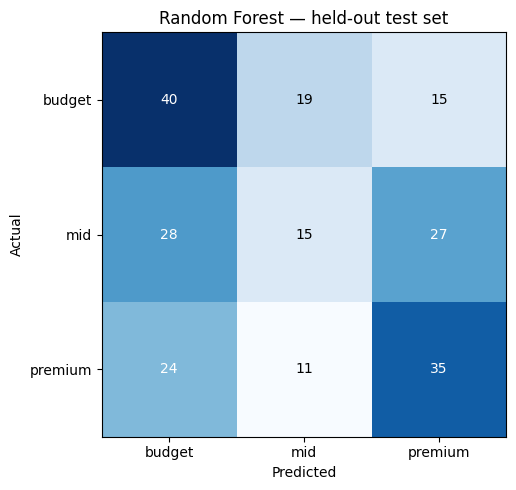

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("text", TfidfVectorizer(stop_words="english", max_features=3000,
                             ngram_range=(1, 2), min_df=2, sublinear_tf=True),
     "text_features"),
    ("cat", OneHotEncoder(handle_unknown="ignore"), ["search_keyword"]),
    ("num", StandardScaler(), num_cols),
])

pipelines = {
    "Logistic Regression": Pipeline([("prep", preprocessor),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))]),
    "Random Forest": Pipeline([("prep", preprocessor),
        ("clf", RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                       random_state=42, n_jobs=-1))]),
    "Gradient Boosting": Pipeline([("prep", preprocessor),
        ("clf", GradientBoostingClassifier(n_estimators=200, random_state=42))]),
}

feature_cols = ["text_features", "search_keyword"] + num_cols
Xtr_raw = X_train_df[feature_cols]
Xte_raw = X_test_df[feature_cols]

print("=" * 70)
print("MODEL SELECTION — 5-fold CV on training data only")
print("Preprocessing fitted inside each fold (no leakage)")
print("=" * 70)

cv_results = []
for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, Xtr_raw, y_train, cv=cv, scoring="f1_macro", n_jobs=-1)
    cv_results.append({"model": name, "cv_macro_f1": scores.mean(), "cv_std": scores.std()})
    print(f"{name:22s}  {scores.mean():.3f} (+/- {scores.std():.3f})")

cv_df = pd.DataFrame(cv_results).sort_values("cv_macro_f1", ascending=False).round(3)
display(cv_df)

selected_name = cv_df.iloc[0]["model"]
print(f"\nSelected by CV: {selected_name}")

print("\n" + "=" * 70)
print("FINAL EVALUATION — held-out test set, used once")
print("=" * 70)

final_pipe = pipelines[selected_name]
final_pipe.fit(Xtr_raw, y_train)
final_pred = final_pipe.predict(Xte_raw)

print(f"Model: {selected_name}")
print(f"Test accuracy: {accuracy_score(y_test, final_pred):.3f}")
print(f"Test macro-F1: {f1_score(y_test, final_pred, average='macro'):.3f}\n")
print(classification_report(y_test, final_pred,
                            labels=["budget", "mid-range", "premium"],
                            digits=3, zero_division=0))

cm = confusion_matrix(y_test, final_pred, labels=["budget", "mid-range", "premium"])
fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(3)); ax.set_xticklabels(["budget", "mid", "premium"])
ax.set_yticks(range(3)); ax.set_yticklabels(["budget", "mid", "premium"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"{selected_name} — held-out test set")
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black")
plt.tight_layout()
plt.show()

In [7]:
import os, joblib, shutil
os.makedirs("/kaggle/working/models", exist_ok=True)

joblib.dump(final_pipe, "/kaggle/working/models/feature_d_price_tier_pipeline.joblib")
cv_df.to_csv("/kaggle/working/models/feature_d_cv_selection.csv", index=False)

final_eval = pd.DataFrame([{
    "selected_model": selected_name,
    "cv_macro_f1": cv_df.iloc[0]["cv_macro_f1"],
    "cv_std": cv_df.iloc[0]["cv_std"],
    "test_accuracy": accuracy_score(y_test, final_pred),
    "test_macro_f1": f1_score(y_test, final_pred, average="macro"),
    "baseline_macro_f1": 0.171,
}])
final_eval.to_csv("/kaggle/working/models/feature_d_evaluation.csv", index=False)

all_products = df.copy()
all_products["bullet_text"] = all_products["bullet_points"].apply(
    lambda b: " ".join(b) if isinstance(b, list) else "")
all_products["text_features"] = (all_products["title"].fillna("") + " " +
                                  all_products["brand"].fillna("") + " " +
                                  all_products["bullet_text"])
all_products["title_length"] = all_products["title"].str.len()
all_products["bullet_count"] = all_products["bullet_points"].apply(
    lambda b: len(b) if isinstance(b, list) else 0)
all_products["has_brand"] = (all_products["brand"].fillna("") != "").astype(int)
all_products["rating"] = all_products["rating"].fillna(all_products["rating"].median())
all_products["review_count"] = all_products["review_count"].fillna(
    all_products["review_count"].median())

all_products["predicted_tier"] = final_pipe.predict(all_products[feature_cols])
all_products[["asin", "search_keyword", "title", "brand", "price",
              "price_was_imputed", "predicted_tier"]].to_csv(
    "/kaggle/working/models/feature_d_predictions.csv", index=False)

shutil.make_archive("/kaggle/working/feature_d_artifacts", "zip", "/kaggle/working/models")
print("Saved and zipped Feature D artifacts")

Saved and zipped Feature D artifacts


In [1]:
import sklearn
print(sklearn.__version__)

1.6.1
